# 08 — Validation d'états sous bruit de mesure : le problème honnête

## Pourquoi ce notebook existe

Le notebook 07 affichait 100 % d'accuracy partout — non parce que le modèle était bon,
mais parce que le label fuyait dans les features (`norm_deviation` = |Σ|cᵢ|² − 1| **est**
la définition de `is_valid`). Voir l'avertissement en tête du notebook 07 et l'audit
`reports/AUDIT_2026-07-07.md` §4.

Le diagnostic profond : **sur amplitudes exactes, la validité est calculable, pas apprenable.**
Σᵢ|cᵢ|² = 1 est une fonction déterministe des features. Le ML n'y a aucun métier.

## La reformulation physique

En pratique, on n'a jamais accès aux amplitudes exactes. Un état est *reconstruit* par
**tomographie** à partir d'un budget fini de N mesures. Chaque composante est estimée avec
une erreur statistique — le bruit de grenaille (*shot noise*) :

$$\hat{c}_i = c_i + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0, \sigma^2), \qquad \sigma = \frac{1}{2\sqrt{N}}$$

**Lecture** : « c-i-chapeau égale c-i plus epsilon-i, où epsilon suit une loi normale centrée
d'écart-type sigma égal à un sur deux racine de N ». Plus on mesure (N grand), plus σ est
petit — la précision croît en racine de N, jamais plus vite : c'est la loi universelle de la
statistique de comptage.

Conséquence : la norme estimée $\|\hat{\psi}\|^2$ fluctue autour de $\|\psi\|^2$.
Près de la frontière ‖ψ‖² = 1, **les classes se chevauchent réellement** : décider devient
un problème statistique légitime, avec de vrais faux positifs, de vrais compromis, et une
difficulté pilotée par N.

## Lien aérospatial

C'est exactement le problème opérationnel des capteurs quantiques embarqués : une horloge
atomique de satellite GNSS, un gyromètre à interférométrie atomique de centrale inertielle
ou un lien QKD par satellite doivent **qualifier leurs états à partir de statistiques
finies**. Le budget N, c'est du temps d'intégration, de l'énergie, de la liaison
descendante — des ressources de mission. Le taux de faux positifs, c'est du risque mission.
Ce notebook est un modèle réduit fidèle de ce sous-système de qualification.

In [1]:
# Bootstrap : rendre src/ importable quel que soit le cwd
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
assert (ROOT / "src").exists(), "Racine du projet introuvable"
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.paths import MAIN_DATASET
from src.features import (
    add_measurement_noise,
    compute_features,
    sigma_from_shots,
)

RANDOM_STATE = 42
%matplotlib inline

df = pd.read_csv(MAIN_DATASET)
print(f"Dataset : {df.shape[0]} états, dim=4, "
      f"{df['is_valid'].mean():.0%} valides")

Dataset : 10000 états, dim=4, 50% valides


## 1. Ce que le bruit fait à la norme estimée

Pour chaque budget de mesures N, on simule la reconstruction tomographique du dataset
entier, puis on regarde la distribution de $\|\hat{\psi}\|^2$ par classe.

**Subtilité importante — le biais de l'estimateur.** En développant le carré :

$$\mathbb{E}\big[\|\hat{\psi}\|^2\big] = \|\psi\|^2 + 2d\,\sigma^2$$

**Lecture** : « l'espérance de la norme estimée au carré vaut la vraie norme au carré plus
deux d sigma carré ». Chacune des 2d composantes réelles/imaginaires apporte
$\mathbb{E}[\varepsilon^2] = \sigma^2$ : le bruit ne se moyenne pas à zéro dans un carré.
Un validateur naïf qui compare $\|\hat{\psi}\|^2$ à 1 sans corriger ce biais sera
systématiquement décalé — erreur classique d'instrumentation, la même qui impose de
calibrer le biais d'un gyromètre avant le vol.

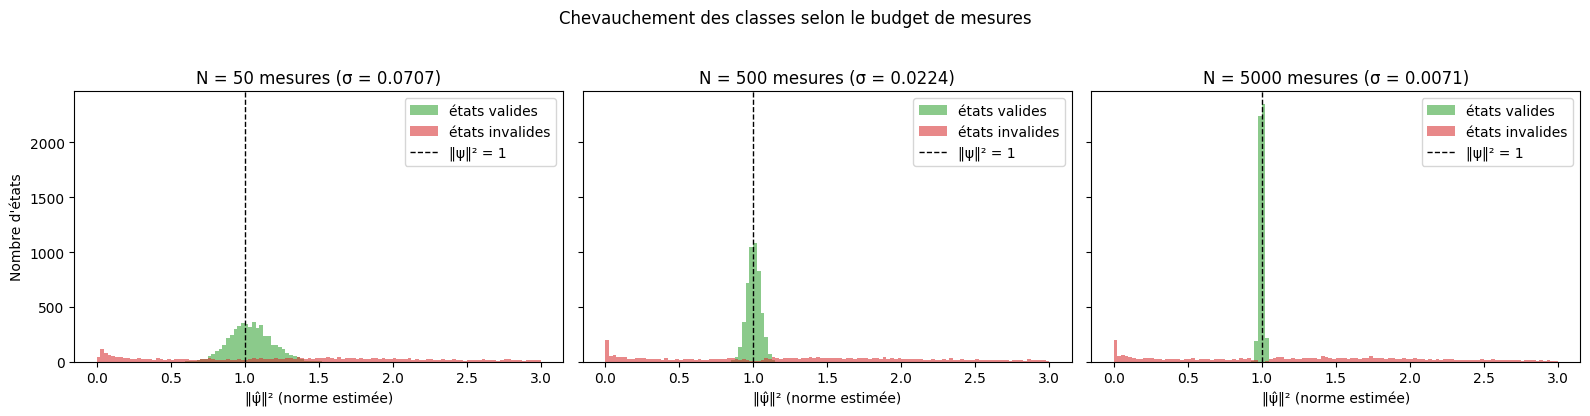

N=   50 : ‖ψ̂‖² des états VALIDES : moyenne=1.0398 (biais théorique 2dσ² = 0.0400), écart-type=0.1442
N=  500 : ‖ψ̂‖² des états VALIDES : moyenne=1.0040 (biais théorique 2dσ² = 0.0040), écart-type=0.0453
N= 5000 : ‖ψ̂‖² des états VALIDES : moyenne=1.0004 (biais théorique 2dσ² = 0.0004), écart-type=0.0143


In [2]:
SHOT_BUDGETS = [50, 500, 5000]
DIM = 4

noisy = {N: add_measurement_noise(df, n_shots=N, seed=RANDOM_STATE)
         for N in SHOT_BUDGETS}

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, N in zip(axes, SHOT_BUDGETS):
    d = noisy[N]
    sigma = sigma_from_shots(N)
    for label, color, name in [(1, "tab:green", "valides"),
                               (0, "tab:red", "invalides")]:
        vals = d.loc[d["is_valid"] == label, "norm_squared"]
        ax.hist(vals, bins=120, range=(0, 3), alpha=0.55,
                color=color, label=f"états {name}")
    ax.axvline(1.0, color="k", ls="--", lw=1, label="‖ψ‖² = 1")
    ax.set_title(f"N = {N} mesures (σ = {sigma:.4f})")
    ax.set_xlabel("‖ψ̂‖² (norme estimée)")
    ax.legend()
axes[0].set_ylabel("Nombre d'états")
fig.suptitle("Chevauchement des classes selon le budget de mesures", y=1.03)
plt.tight_layout()
plt.show()

for N in SHOT_BUDGETS:
    d = noisy[N]
    v = d.loc[d.is_valid == 1, "norm_squared"]
    print(f"N={N:5d} : ‖ψ̂‖² des états VALIDES : "
          f"moyenne={v.mean():.4f} (biais théorique 2dσ² = {2*DIM*sigma_from_shots(N)**2:.4f}), "
          f"écart-type={v.std():.4f}")

**Interprétation.** À N = 50, les distributions se recouvrent largement autour de la
frontière : aucun classifieur, aussi sophistiqué soit-il, ne peut être parfait — c'est la
physique qui l'interdit, pas l'algorithme. À N = 5000, le recouvrement devient marginal.
Le biais mesuré colle à la prédiction 2dσ² : notre modèle de bruit se comporte comme
la théorie l'annonce. **N est le curseur de difficulté du problème.**

## 2. Entraînement sur données bruitées

Sur données bruitées, `norm_squared` et `norm_deviation` ne sont plus des « triches » :
ce sont des **estimateurs** calculés sur les amplitudes observées — exactement ce dont
dispose un expérimentateur. Le label, lui, reste la validité de l'état *sous-jacent* :
c'est ce qu'on demande au modèle de retrouver à travers le bruit.

On compare une régression logistique (linéaire) et un Random Forest, avec les features
du module `src/features.py` (invariantes + sensibles, `kind="all"`).

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

results = {}
for N in SHOT_BUDGETS:
    d = noisy[N]
    X = compute_features(d, kind="all")
    y = d["is_valid"]

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

    # Scaling : nécessaire pour la régression logistique (descente de gradient,
    # régularisation isotrope) — inutile pour le Random Forest, invariant par
    # transformation monotone de chaque feature (erreur conceptuelle du nb 07).
    scaler = StandardScaler().fit(X_tr)

    logreg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
    logreg.fit(scaler.transform(X_tr), y_tr)
    p_lr = logreg.predict_proba(scaler.transform(X_te))[:, 1]

    rf = RandomForestClassifier(n_estimators=100, max_depth=None,
                                random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    p_rf = rf.predict_proba(X_te)[:, 1]

    results[N] = {
        "y_test": y_te,
        "acc_lr": accuracy_score(y_te, p_lr > 0.5),
        "acc_rf": accuracy_score(y_te, p_rf > 0.5),
        "auc_lr": roc_auc_score(y_te, p_lr),
        "auc_rf": roc_auc_score(y_te, p_rf),
        "proba_rf": p_rf,
        "X_test": X_te,
    }
    print(f"N={N:5d} | LogReg : acc={results[N]['acc_lr']:.4f} "
          f"AUC={results[N]['auc_lr']:.4f} | "
          f"RF : acc={results[N]['acc_rf']:.4f} AUC={results[N]['auc_rf']:.4f}")

N=   50 | LogReg : acc=0.6028 AUC=0.6657 | RF : acc=0.9060 AUC=0.9398


N=  500 | LogReg : acc=0.6020 AUC=0.6501 | RF : acc=0.9736 AUC=0.9866


N= 5000 | LogReg : acc=0.6060 AUC=0.6734 | RF : acc=0.9976 AUC=0.9987


**Des chiffres honnêtes — et un échec instructif.** L'accuracy n'est plus 1.0000 :
elle croît avec N et sature vers 1 quand le bruit devient négligeable — le comportement
attendu d'un vrai problème statistique.

Mais le résultat le plus instructif est **l'effondrement de la régression logistique
(~60 %, à peine mieux que le hasard)** là où la forêt dépasse 91 %. Deux causes se
combinent :

1. **Géométrie de décision non linéaire** : la classe « valide » vit dans une *bande*
   ‖ψ̂‖² ∈ [1−t, 1+t]. Une frontière linéaire ne peut pas découper un intervalle borné
   des deux côtés dans l'espace des features brutes ; un arbre le fait avec deux splits.
2. **Queues lourdes** : les états extrêmes du dataset poussent `purity_raw` jusqu'à ~10⁸.
   La standardisation (moyenne/écart-type) est écrasée par ces outliers : pour l'immense
   majorité des points, les features standardisées se retrouvent comprimées près de zéro,
   et le gradient de la régression n'a plus de signal exploitable.

**Leçon** : la *représentation* des données compte plus que la puissance de l'algorithme.
La section suivante le démontre par l'absurde : avec la bonne statistique (une seule
feature bien construite), un seuil à un paramètre suffit.


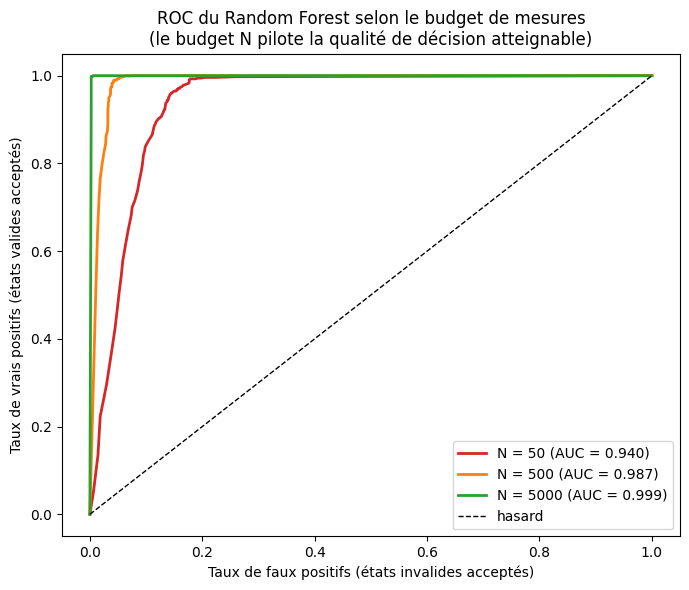

In [4]:
fig, ax = plt.subplots(figsize=(7, 6))
colors = {50: "tab:red", 500: "tab:orange", 5000: "tab:green"}
for N in SHOT_BUDGETS:
    fpr, tpr, _ = roc_curve(results[N]["y_test"], results[N]["proba_rf"])
    ax.plot(fpr, tpr, color=colors[N], lw=2,
            label=f"N = {N} (AUC = {results[N]['auc_rf']:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="hasard")
ax.set_xlabel("Taux de faux positifs (états invalides acceptés)")
ax.set_ylabel("Taux de vrais positifs (états valides acceptés)")
ax.set_title("ROC du Random Forest selon le budget de mesures\n"
             "(le budget N pilote la qualité de décision atteignable)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 3. Le juge de paix : comparaison au test statistique optimal

La théorie de la décision dit que pour ce problème, la statistique suffisante est la norme
estimée. Le test optimal (à la structure près) est un **seuil bilatéral corrigé du biais** :

$$\text{rejeter la validité si } \big|\,\|\hat{\psi}\|^2 - 1 - 2d\sigma^2\,\big| > t$$

**Lecture** : « rejeter si l'écart entre la norme estimée corrigée du biais et un dépasse
le seuil t ». Un seul paramètre t, ajusté sur le train. Si nos modèles ML à 8 features ne
battent pas ce test à 1 paramètre, c'est que toute l'information utile tient dans la norme —
ce que la physique nous a déjà dit.

In [5]:
from sklearn.tree import DecisionTreeClassifier

print(f"{'N':>6} | {'Test seuil (1 param)':>21} | {'LogReg':>8} | {'RF':>8}")
print("-" * 55)
for N in SHOT_BUDGETS:
    d = noisy[N]
    sigma = sigma_from_shots(N)
    # Statistique de test : |‖ψ̂‖² − 1 − 2dσ²|
    stat = np.abs(d["norm_squared"] - 1.0 - 2 * DIM * sigma**2).to_frame("t_stat")
    y = d["is_valid"]
    s_tr, s_te, y_tr, y_te = train_test_split(
        stat, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
    # Un stump (arbre de profondeur 1) apprend exactement « t_stat > t »
    stump = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)
    stump.fit(s_tr, y_tr)
    acc_stump = accuracy_score(y_te, stump.predict(s_te))
    print(f"{N:>6} | {acc_stump:>21.4f} | "
          f"{results[N]['acc_lr']:>8.4f} | {results[N]['acc_rf']:>8.4f}")

     N |  Test seuil (1 param) |   LogReg |       RF
-------------------------------------------------------
    50 |                0.9132 |   0.6028 |   0.9060
   500 |                0.9724 |   0.6020 |   0.9736
  5000 |                0.9972 |   0.6060 |   0.9976


## Conclusion

Trois enseignements, du plus technique au plus fondamental :

1. **Le test à un paramètre fait jeu égal avec le Random Forest à tous les N** (écarts ≤ 0.5 point, dans le bruit d'échantillonnage — il le bat même à N=50) et écrase la régression logistique. Toute l'information de
   validité tient dans ‖ψ̂‖² : les 8 features et la forêt de 100 arbres
   n'apportent rien de plus que ce que la structure du problème contient. Comprendre le
   problème avant de le modéliser aurait économisé un notebook entier — c'est la leçon
   du 07.

2. **La performance est désormais pilotée par la physique** (le budget N), pas par
   l'algorithme. Pour un ingénieur système, la question intéressante n'est plus
   « quel modèle ? » mais « **quel N minimal pour un taux de faux positifs
   contractuel ?** » — dimensionnement d'un budget de mesures, exactement comme on
   dimensionne le temps d'intégration d'une horloge atomique GNSS pour tenir une
   spécification de stabilité, ou le nombre de photons d'une session QKD satellite
   pour borner le taux d'erreur.

3. **Le ML retrouve sa juste place** : ici, une baseline de vérification. Il deviendra
   réellement utile quand le problème se complexifiera — bruit corrélé entre composantes,
   erreurs systématiques de calibration, classification de la *cause* d'invalidité
   (scaling / noise / extreme), dimensions variables. C'est la roadmap du jalon 4.

*Modules associés : `src/features.py` (features et bruit), `src/data_generation.py`
(garantie de frontière F2). Tests : `tests/test_features.py`.*